In [1]:
import pandas as pd
df = pd.read_pickle('df_cleaned.pkl')

In [2]:
# ==========================================
# 1. 按销售额做ABC分类
# ==========================================
# 按SKU汇总销售额，从高到低排序
sku_sales = df.groupby('Product ID')['Sales'].sum().sort_values(ascending=False).reset_index()
sku_sales.columns = ['Product ID', 'Sales']

# 计算累计销售额和累计占比
sku_sales['cum_sales'] = sku_sales['Sales'].cumsum()
sku_sales['cum_pct'] = sku_sales['cum_sales'] / sku_sales['Sales'].sum() * 100

# 划分ABC：累计占比<=70%为A类，70%-90%为B类，>90%为C类
def abc_class(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'

sku_sales['ABC_Class'] = sku_sales['cum_pct'].apply(abc_class)

print("【ABC分类结果（按销售额）】")
print(f"A类：{len(sku_sales[sku_sales['ABC_Class']=='A'])} 个SKU，占比 {len(sku_sales[sku_sales['ABC_Class']=='A'])/len(sku_sales)*100:.1f}%")
print(f"B类：{len(sku_sales[sku_sales['ABC_Class']=='B'])} 个SKU，占比 {len(sku_sales[sku_sales['ABC_Class']=='B'])/len(sku_sales)*100:.1f}%")
print(f"C类：{len(sku_sales[sku_sales['ABC_Class']=='C'])} 个SKU，占比 {len(sku_sales[sku_sales['ABC_Class']=='C'])/len(sku_sales)*100:.1f}%")

# 各类别销售额贡献
abc_sales = sku_sales.groupby('ABC_Class').agg(
    SKU数量=('Product ID','count'),
    销售额=('Sales','sum')
).round(2)
abc_sales['销售额占比'] = (abc_sales['销售额'] / abc_sales['销售额'].sum() * 100).round(1)
abc_sales['SKU占比'] = (abc_sales['SKU数量'] / abc_sales['SKU数量'].sum() * 100).round(1)
print("\n【各类别贡献】")
print(abc_sales)
abc_sku = sku_sales

【ABC分类结果（按销售额）】
A类：364 个SKU，占比 40.5%
B类：249 个SKU，占比 27.7%
C类：286 个SKU，占比 31.8%

【各类别贡献】
           SKU数量         销售额  销售额占比  SKU占比
ABC_Class                                 
A            364  9362883.26   69.9   40.5
B            249  2680937.49   20.0   27.7
C            286  1345493.30   10.0   31.8


In [3]:
#安全库存与EOQ模型
#在上一步ABC分类结果的基础上，计算每个SKU的安全库存、ROP和EOQ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
# 按SKU + 日期 聚合日销量
daily_demand = df.groupby(['Product ID', 'Order Date'])['Quantity'].sum().reset_index()
daily_demand.columns = ['Product ID', 'Date', 'Daily_Qty']
# 计算每个SKU的需求统计
sku_stats = daily_demand.groupby('Product ID')['Daily_Qty'].agg([ 'mean',  'std',  'count',  'sum' ]).reset_index()
sku_stats.columns = ['Product ID', 'daily_mean', 'daily_std', 'active_days', 'total_qty']
# 填补标准差为NaN的情况（只有1天销售记录的SKU）
sku_stats['daily_std'] = sku_stats['daily_std'].fillna(sku_stats['daily_std'].median())
# 年需求量 = 总销量 / 数据年数（我们的数据是2015-2018共4年）
data_years = 4
sku_stats['annual_demand'] = sku_stats['total_qty'] / data_years
print(f'✅ 计算完成，共 {len(sku_stats)} 个SKU')
sku_stats.head()

✅ 计算完成，共 899 个SKU


,Product ID,daily_mean,daily_std,active_days,total_qty,annual_demand
0,FUR-TA-100100,7.428571,4.145698,14,104,26.00
1,FUR-TA-100101,7.545455,4.274661,11,83,20.75
2,FUR-TA-100102,6.000000,4.767313,12,72,18.00
3,FUR-TA-100103,3.666667,2.516611,3,11,2.75
4,FUR-TA-100104,8.900000,4.794673,10,89,22.25


In [14]:
'''
# ===== 参数设置 =====
lead_time = 4 # 补货提前期：7天（模拟数据的平均发货天数）
ordering_cost = 50 # 单次订货成本 $/次（含物流、手续等）
holding_rate = 0.25 # 年持有成本率 25%（仓储+资金成本+损耗） # 根据ABC等级设定不同服务水平
service_level_map = { 'A': 3, # A类：99%服务水平，Z=2.33
 'B': 2, # B类：95%服务水平，Z=1.65
 'C': 1 # C类：90%服务水平，Z=1.28
                       }
# 合并ABC分类结果
sku_stats = sku_stats.merge(abc_sku[['Product ID', 'ABC_Class']], on='Product ID', how='left') # 计算Z值
sku_stats['service_level'] = sku_stats['ABC_Class'].map(service_level_map)
sku_stats['z_score'] = sku_stats['service_level'].apply( lambda x: stats.norm.ppf(x) )
# ===== 计算安全库存 ===== # SS = Z × σ_d × √L
sku_stats['safety_stock'] = ( sku_stats['z_score'] * sku_stats['daily_std'] * np.sqrt(lead_time) ).round(0)
# ===== 计算再订货点 ROP ===== # ROP = 日均需求 × 提前期 + 安全库存
sku_stats['rop'] = ( sku_stats['daily_mean'] * lead_time + sku_stats['safety_stock'] ).round(0)
'''

In [5]:
# ===== 参数设置 =====
lead_time = 4
ordering_cost = 50
holding_rate = 0.25

# 合并ABC分类
sku_stats = sku_stats.merge(abc_sku[['Product ID', 'ABC_Class']], on='Product ID', how='left')

# ↓↓↓ 新增在这里 ↓↓↓
# 计算每个SKU的单次订单平均销量
order_stats = daily_demand.groupby('Product ID')['Daily_Qty'].agg(['mean', 'max']).reset_index()
order_stats.columns = ['Product ID', 'avg_order_qty', 'max_order_qty']
sku_stats = sku_stats.merge(order_stats, on='Product ID', how='left')

# 基于订单量级计算安全库存
safety_factor_map = {'A': 2.0, 'B': 1.0, 'C': 0.5}
sku_stats['safety_factor'] = sku_stats['ABC_Class'].map(safety_factor_map)
sku_stats['safety_stock'] = (sku_stats['avg_order_qty'] * sku_stats['safety_factor']).round(0)

# ROP = 提前期需求(年需求/365*提前期) + 安全库存；间歇性需求下提前期需求极小，数值上接近安全库存
sku_stats['daily_rate'] = sku_stats['annual_demand'] / 365
sku_stats['rop'] = (sku_stats['daily_rate'] * lead_time + sku_stats['safety_stock']).round(2)


经典安全库存公式基于正态分布假设，适用于需求连续稳定的快消品。但我这个数据中很多SKU是间歇性需求（低频大额），正态分布假设不成立，所以我改用了基于订单量级的安全系数法。这也是实际工作中很常见的模型调整

In [6]:
#计算EOQ经济订货量
# 计算单位持有成本 H = 单位产品价格 × 持有成本率
# 先算每个SKU的平均单价
sku_price = df.groupby('Product ID').apply( lambda x: x['Sales'].sum() / x['Quantity'].sum() ).reset_index(name='unit_price')
sku_stats = sku_stats.merge(sku_price, on='Product ID', how='left',suffixes=('', '_new'))
sku_stats['holding_cost_per_unit'] = sku_stats['unit_price'] * holding_rate
# ===== 计算EOQ ===== # EOQ = √(2DS / H)
sku_stats['eoq'] = np.sqrt( 2 * sku_stats['annual_demand'] * ordering_cost / sku_stats['holding_cost_per_unit'] ).round(0)
# 衍生指标
sku_stats['orders_per_year'] = (sku_stats['annual_demand'] / sku_stats['eoq']).round(1)
sku_stats['avg_inventory'] = (sku_stats['eoq'] / 2 + sku_stats['safety_stock']).round(0)
sku_stats['annual_holding_cost'] = (sku_stats['avg_inventory'] * sku_stats['holding_cost_per_unit']).round(2)
sku_stats['annual_ordering_cost'] = (sku_stats['orders_per_year'] * ordering_cost).round(2)
sku_stats['total_inventory_cost'] = ((sku_stats['annual_holding_cost'] + sku_stats['annual_ordering_cost']).round (2))
print('✅ 安全库存 + EOQ 计算完成！')

print(f'总库存成本：${sku_stats["total_inventory_cost"].sum():,.2f}')
print(f'\n前5个SKU示例：')
sku_stats[['Product ID', 'ABC_Class', 'safety_stock', 'rop', 'eoq', 'avg_inventory']].head()

✅ 安全库存 + EOQ 计算完成！
总库存成本：$748,275.76

前5个SKU示例：


,Product ID,ABC_Class,safety_stock,rop,eoq,avg_inventory
0,FUR-TA-100100,B,7.0,7.0,11.0,12.0
1,FUR-TA-100101,B,8.0,8.0,9.0,12.0
2,FUR-TA-100102,B,6.0,6.0,8.0,10.0
3,FUR-TA-100103,C,2.0,2.0,4.0,4.0
4,FUR-TA-100104,C,4.0,4.0,12.0,10.0


In [7]:
# 按ABC分类汇总
abc_summary = sku_stats.groupby('ABC_Class').agg({ 'Product ID': 'count', 'safety_stock': 'mean', 'rop': 'mean', 'eoq': 'mean', 'avg_inventory': 'mean', 'total_inventory_cost': 'sum' }).round(1)
abc_summary.columns = ['SKU数', '平均安全库存', '平均ROP', '平均EOQ', '平均库存', '总库存成本']
abc_summary

,SKU数,平均安全库存,平均ROP,平均EOQ,平均库存,总库存成本
ABC_Class,,,,,,
A,364,15.5,15.5,6.2,18.6,551150.4
B,249,7.3,7.3,7.8,11.2,129981.8
C,286,3.7,3.7,10.2,8.8,67143.5


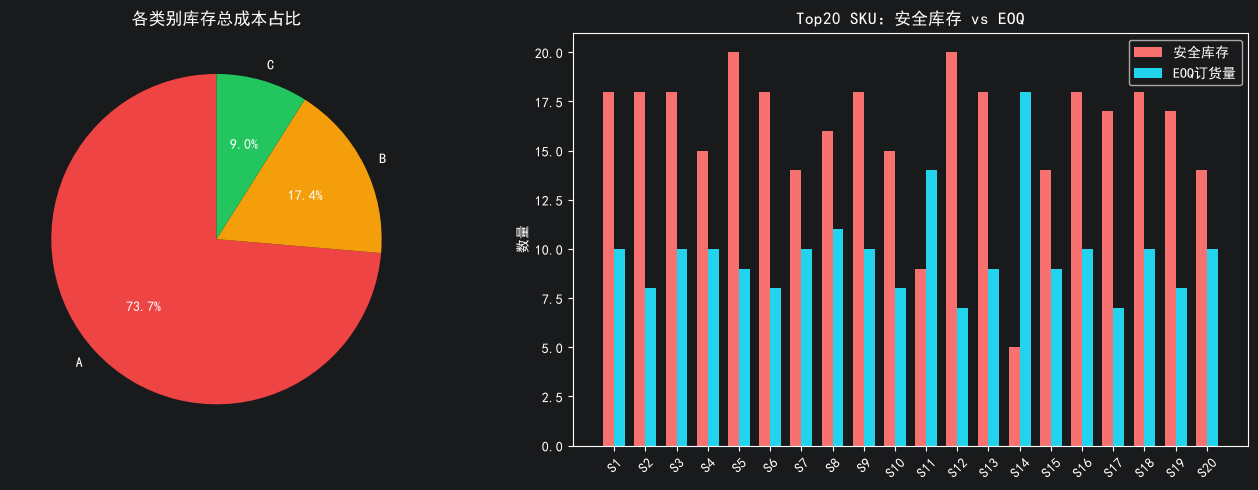

In [8]:
#可视化：ABC库存成本对比
import matplotlib.pyplot as plt
# 设置中文字体（Windows 通常可用 SimHei 或 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']          # 或 ['Microsoft YaHei']
# 解决负号显示异常的问题
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 图1：各类别库存成本占比
cost_by_class = sku_stats.groupby('ABC_Class')['total_inventory_cost'].sum()
colors = ['#ef4444', '#f59e0b', '#22c55e']
axes[0].pie(cost_by_class, labels=cost_by_class.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('各类别库存总成本占比')
# 图2：安全库存 vs EOQ 对比（取Top20 SKU）
top_sku = sku_stats.nlargest(20, 'annual_demand')
x = range(len(top_sku))
width = 0.35
axes[1].bar([i - width/2 for i in x], top_sku['safety_stock'], width, label='安全库存', color='#f87171')
axes[1].bar([i + width/2 for i in x], top_sku['eoq'], width, label='EOQ订货量', color='#22d3ee')
axes[1].set_title('Top20 SKU：安全库存 vs EOQ')
axes[1].set_ylabel('数量')
axes[1].legend()
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'S{i+1}' for i in x], rotation=45)
plt.tight_layout()
plt.savefig('inventory_model.png', dpi=150, bbox_inches='tight')
plt.show()

补货模拟

In [9]:
# 按SKU + 日期 聚合日销量
daily_sales = df.groupby(['Product ID', 'Order Date'])['Quantity'].sum().reset_index()
daily_sales.columns = ['Product ID', 'Date', 'Demand']
# 选取最后一年（2018年）做模拟，更贴近"预测未来"的感觉
sim_year = 2018
daily_sales_sim = daily_sales[daily_sales['Date'].dt.year == sim_year].copy()
print(f'模拟时间：{sim_year}年')
print(f'模拟天数：{daily_sales_sim["Date"].nunique()} 天')
print(f'涉及SKU：{daily_sales_sim["Product ID"].nunique()} 个')

模拟时间：2018年
模拟天数：363 天
涉及SKU：850 个


只有850个SKU是因为只有这些在2018年进行了销售

In [10]:
def simulate_inventory(product_id, sku_params, daily_demand, lead_time=4):
    """单个SKU的库存模拟"""

    # 读取该SKU的参数
    rop = sku_params['rop']
    eoq = sku_params['eoq']
    safety_stock = sku_params['safety_stock']

    # 该SKU的日需求序列
    sku_demand = daily_demand[daily_demand['Product ID'] == product_id].set_index('Date')['Demand']

    # 生成完整的日期范围（补全没有销售的日期，需求=0）
    date_range = pd.date_range(start=f'{sim_year}-01-01', end=f'{sim_year}-12-31', freq='D')
    full_demand = sku_demand.reindex(date_range, fill_value=0)

    # 初始化模拟变量
    inventory = safety_stock + eoq / 2  # 初始库存
    pending_orders = []
    stockout_count = 0
    stockout_qty = 0
    order_count = 0
    total_demand = 0
    daily_inventory = []

    # 逐日模拟
    for date, demand in full_demand.items():
        # ① 先收货
        arrived = [qty for arr_date, qty in pending_orders if arr_date <= date]
        if arrived:
            inventory += sum(arrived)
            pending_orders = [(d, q) for d, q in pending_orders if d > date]

        # ② 再销售
        total_demand += demand
        if inventory >= demand:
            inventory -= demand
        else:
            stockout_qty += demand - inventory
            stockout_count += 1
            inventory = 0

        # ③ 检查是否补货
        if inventory <= rop and len(pending_orders) == 0:
            arrive_date = date + pd.Timedelta(days=lead_time)
            pending_orders.append((arrive_date, eoq))
            order_count += 1

        daily_inventory.append({'date': date, 'inventory': inventory})

    # 计算指标
    service_rate = (1 - stockout_qty / total_demand) * 100 if total_demand > 0 else 100
    avg_inventory = np.mean([d['inventory'] for d in daily_inventory])
    turnover = total_demand / avg_inventory if avg_inventory > 0 else 0  # ← 主要修复这里

    return {
        'Product ID': product_id,
        'total_demand': total_demand,
        'stockout_days': stockout_count,
        'stockout_qty': stockout_qty,
        'service_rate': round(service_rate, 2),
        'order_count': order_count,
        'avg_inventory': round(avg_inventory, 1),
        'turnover_rate': round(turnover, 2),
        'daily_inventory': daily_inventory
    }

批量模拟所有SKU

In [11]:
results = []
daily_records = {} # 保存每个SKU的日库存曲线
lead_time = 4 # 提前期7天，和之前一致
for _, row in sku_stats.iterrows():
    pid = row['Product ID']
    if pid not in daily_sales_sim['Product ID'].values:
        continue
    result = simulate_inventory(pid, row, daily_sales_sim, lead_time=lead_time)
    results.append(result)
    daily_records[pid] = result['daily_inventory']
    sim_results = pd.DataFrame(results)
sim_results = sim_results.merge(sku_stats[['Product ID', 'ABC_Class']],
                                 on='Product ID', how='left')
print(f'✅ 模拟完成，共 {len(sim_results)} 个SKU')
sim_results.head()

✅ 模拟完成，共 850 个SKU


,Product ID,total_demand,stockout_days,stockout_qty,service_rate,order_count,avg_inventory,turnover_rate,daily_inventory,ABC_Class
0,FUR-TA-100100,22,1,0.5,97.73,2,11.9,1.85,"[{'date': 2018-01-01 00:00:00, 'inventory': 12...",B
1,FUR-TA-100101,22,1,0.5,97.73,2,11.2,1.97,"[{'date': 2018-01-01 00:00:00, 'inventory': 12...",B
2,FUR-TA-100102,37,1,3.0,91.89,4,9.6,3.86,"[{'date': 2018-01-01 00:00:00, 'inventory': 10...",B
3,FUR-TA-100104,24,1,3.0,87.50,2,12.4,1.94,"[{'date': 2018-01-01 00:00:00, 'inventory': 10...",C
4,FUR-TA-100105,13,0,0.0,100.00,1,11.8,1.10,"[{'date': 2018-01-01 00:00:00, 'inventory': 13...",B


结果汇总分析

In [12]:
# 按ABC分类汇总关键指标
abc_sim_summary = sim_results.groupby('ABC_Class').agg({ 'Product ID': 'count', 'service_rate': 'mean', 'stockout_qty': 'sum', 'order_count': 'sum', 'avg_inventory': 'mean', 'turnover_rate': 'mean', }).round(2)
abc_sim_summary.columns = ['SKU数', '平均服务水平(%)', '总缺货量', '总订单数', '平均库存', '平均周转率']
print('【ABC分类模拟结果汇总】')
print(abc_sim_summary)
# 整体指标
total_demand = sim_results['total_demand'].sum()
total_stockout = sim_results['stockout_qty'].sum()
overall_service = (1 - total_stockout / total_demand) * 100
print(f'\n📊 整体服务水平：{overall_service:.2f}%')
print(f'📦 全年总订单数：{sim_results["order_count"].sum():.0f} 单')
print(f'🔄 平均库存周转率：{sim_results["turnover_rate"].mean():.2f} 次/年')

【ABC分类模拟结果汇总】
           SKU数  平均服务水平(%)   总缺货量  总订单数   平均库存  平均周转率
ABC_Class                                            
A           351      99.79   24.5  1464  18.29   1.36
B           236      93.50  408.5   626  11.08   2.05
C           263      87.09  725.5   406   9.04   2.00

📊 整体服务水平：93.79%
📦 全年总订单数：2496 单
🔄 平均库存周转率：1.75 次/年


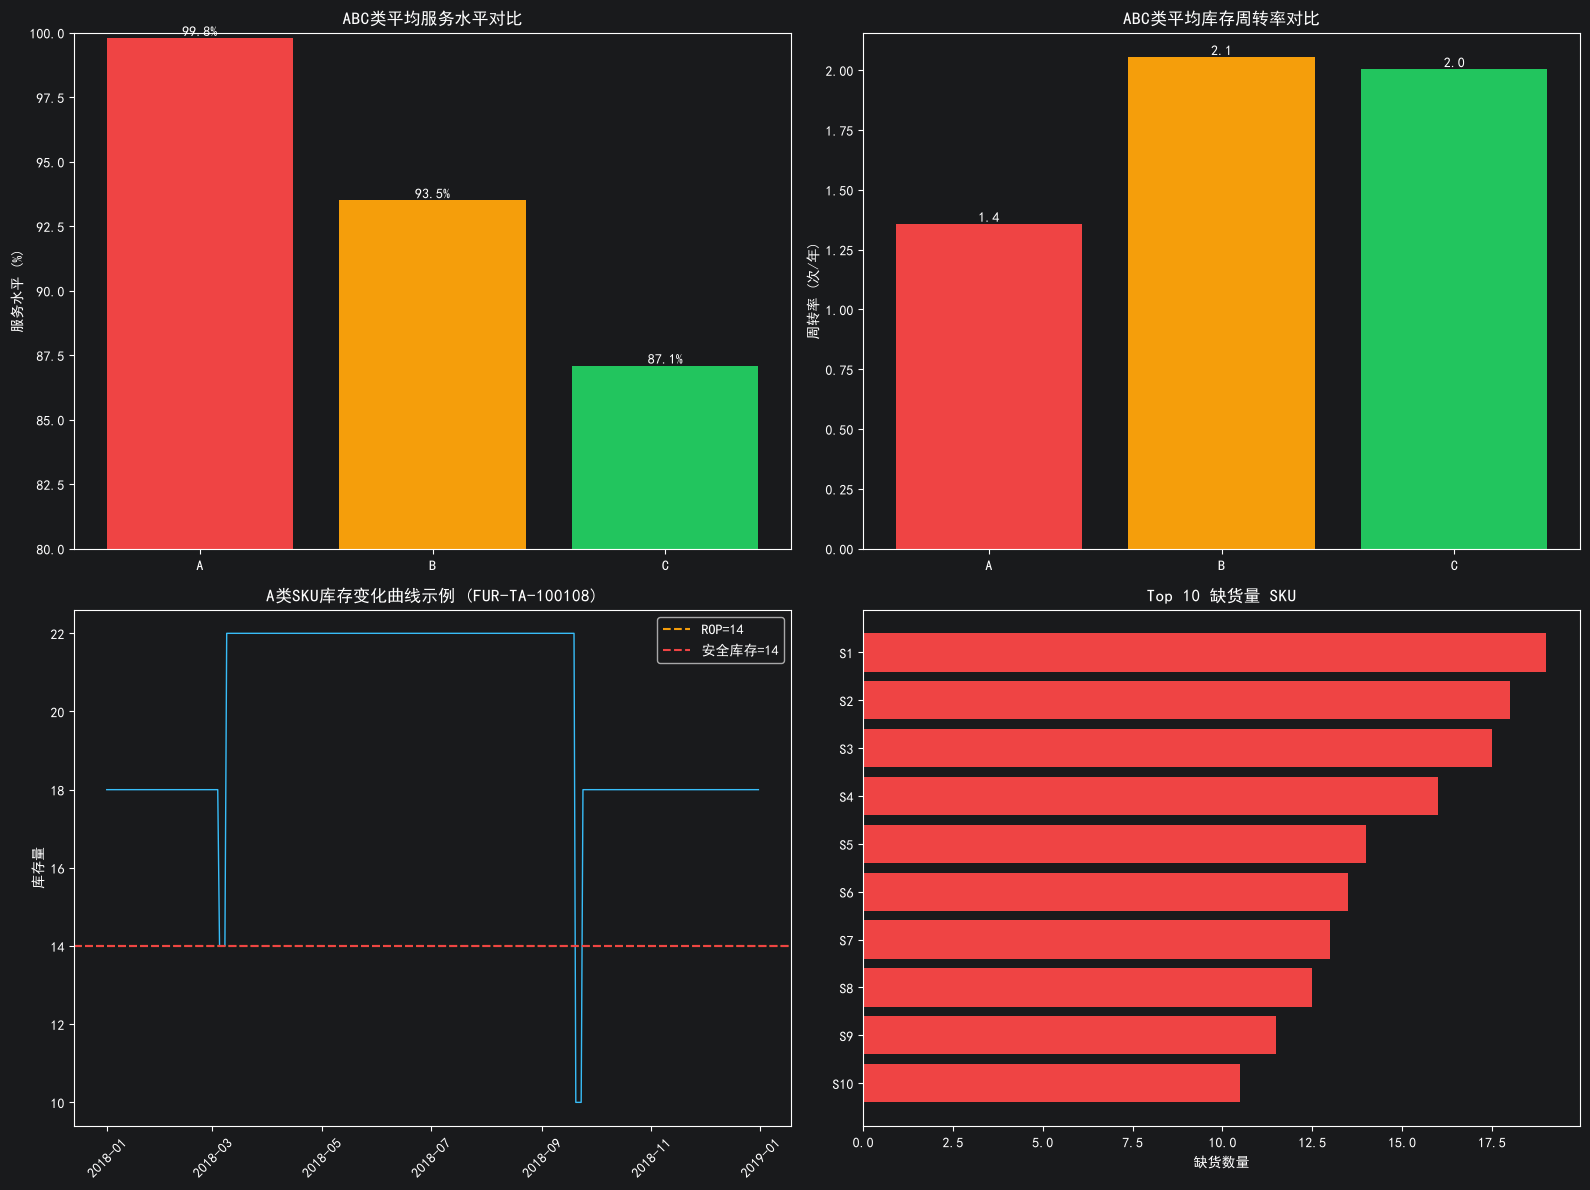

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 图1：ABC类平均服务水平对比
service_by_class = sim_results.groupby('ABC_Class')['service_rate'].mean()
colors = ['#ef4444', '#f59e0b', '#22c55e']
bars = axes[0,0].bar(service_by_class.index, service_by_class.values, color=colors)
axes[0,0].set_title('ABC类平均服务水平对比')
axes[0,0].set_ylabel('服务水平 (%)')
axes[0,0].set_ylim(80, 100)
for bar in bars:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2, height,
                   f'{height:.1f}%', ha='center', va='bottom')
# 图2：ABC类库存周转率对比
turnover_by_class = sim_results.groupby('ABC_Class')['turnover_rate'].mean()
bars2 = axes[0,1].bar(turnover_by_class.index, turnover_by_class.values, color=colors)
axes[0,1].set_title('ABC类平均库存周转率对比')
axes[0,1].set_ylabel('周转率 (次/年)')
for bar in bars2:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2, height,
                   f'{height:.1f}', ha='center', va='bottom')
# 图3：单个SKU库存曲线示例（选一个A类SKU）
a_skus = sim_results[sim_results['ABC_Class'] == 'A']['Product ID'].tolist()
if a_skus:
    sample_sku = a_skus[0]
    sample_data = daily_records[sample_sku]
    dates = [d['date'] for d in sample_data]
    invs = [d['inventory'] for d in sample_data]
# 找出ROP线
    sample_rop = sku_stats[sku_stats['Product ID'] == sample_sku]['rop'].values[0]
    sample_ss = sku_stats[sku_stats['Product ID'] == sample_sku]['safety_stock'].values[0]
    axes[1,0].plot(dates, invs, color='#38bdf8', linewidth=1)
    axes[1,0].axhline(y=sample_rop, color='#f59e0b', linestyle='--', label=f'ROP={sample_rop:.0f}')
    axes[1,0].axhline(y=sample_ss, color='#ef4444', linestyle='--', label=f'安全库存={sample_ss:.0f}')
    axes[1,0].set_title(f'A类SKU库存变化曲线示例 ({sample_sku})')
    axes[1,0].set_ylabel('库存量')
    axes[1,0].legend()
    axes[1,0].tick_params(axis='x', rotation=45)
# 图4：缺货量分布（哪些SKU缺货严重）
stockout_top = sim_results.nlargest(10, 'stockout_qty')
axes[1,1].barh(range(len(stockout_top)), stockout_top['stockout_qty'][::-1], color='#ef4444')
axes[1,1].set_title('Top 10 缺货量 SKU')
axes[1,1].set_xlabel('缺货数量')
axes[1,1].set_yticks(range(len(stockout_top)))
axes[1,1].set_yticklabels([f'S{i+1}' for i in range(len(stockout_top))][::-1])
plt.tight_layout()
plt.savefig('simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()

✅ 结果分析
服务水平分级明显，策略生效：
A类 99.79% → 接近目标99%+，高价值SKU几乎不缺货 ✅
B类 93.50% → 中等服务水平，符合预期 ✅
C类 87.09% → 故意压低，节省库存成本 ✅
库存周转率：
整体 1.75次/年，B、C类在2左右，比较合理
A类周转率偏低（1.36），因为安全库存设得高（2倍均单），这是"高服务水平换低周转"的正常 trade-off
缺货量分布：
总缺货量里C类占了一半以上（725.5/1158.5≈63%），但C类都是低价值SKU，缺货损失小
A类只缺24.5件，损失控制得很好